<a href="https://colab.research.google.com/github/NataKrj/Automated-Risk-Scoring-System/blob/main/MT_training_data%3B_H2O%3B_4_models_with_100_scenarios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [ ]:
!pip install river scikit-learn xgboost pandas numpy matplotlib

In [ ]:
!pip install h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 MB 3.3 MB/s eta 0:00:00


#Training and testing data 1-5

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ── CONFIG ──────────────────────────────────────────────────────────────
CSV_WAVES = [
    "synthetic_transactions_structured1.csv",
    "synthetic_transactions_structured2.csv",
    "synthetic_transactions_structured3.csv",
    "synthetic_transactions_structured4.csv",
    "synthetic_transactions_structured5.csv",
]
TARGET_COL = "Suspicion Category"  # label
TEST_SIZE  = 0.20                   # 20 % hold‑out per wave
RAND_SEED  = 42                     # reproducibility
# ────────────────────────────────────────────────────────────────────────

for wave_idx, csv_path in enumerate(CSV_WAVES, start=1):
    print(f"\nProcessing {csv_path} → Wave {wave_idx}")

    df = pd.read_csv(csv_path)

    if TARGET_COL not in df.columns:
        raise KeyError(f"Target column '{TARGET_COL}' not found in {csv_path}")

    y = df[TARGET_COL]
    X = df.drop(columns=[TARGET_COL])  # keep *all* other columns, incl. Transaction_id

    # Attempt a stratified split; fallback to random split if strata too small
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=TEST_SIZE, stratify=y, random_state=RAND_SEED
        )
    except ValueError as err:
        print(f"  Stratified split failed: {err}\n  Falling back to unstratified split.")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RAND_SEED
        )

    # Re‑attach target for saving
    train_df = X_train.assign(**{TARGET_COL: y_train})
    test_df  = X_test.assign(**{TARGET_COL: y_test})

    train_file = f"training_wave_{wave_idx}.csv"
    test_file  = f"testing_wave_{wave_idx}.csv"

    train_df.to_csv(train_file, index=False)
    test_df.to_csv(test_file,  index=False)

    print(f"  → saved {train_file} ({len(train_df)} rows) and {test_file} ({len(test_df)} rows)")


Processing synthetic_transactions_structured1.csv → Wave 1
  Stratified split failed: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.
  Falling back to unstratified split.
  → saved training_wave_1.csv (8024 rows) and testing_wave_1.csv (2007 rows)

Processing synthetic_transactions_structured2.csv → Wave 2
  Stratified split failed: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.
  Falling back to unstratified split.
  → saved training_wave_2.csv (8024 rows) and testing_wave_2.csv (2006 rows)

Processing synthetic_transactions_structured3.csv → Wave 3
  Stratified split failed: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.
  Falling back to unstratified split.
  → saved training_wave_3.csv (8013 rows) and testing_wave_3.csv (200

#H2O

In [ ]:
import h2o, pandas as pd
from h2o.automl import H2OAutoML
from pathlib import Path

# ---------- CONFIG ---------------------------------------------------- #
TARGET       = "Suspicion Category"
ID_COLS      = ["Transaction_id"]
TIME_BUDGET  = 600
TRAIN_FILES  = [f"training_wave_{i}.csv" for i in range(1, 6)]
TEST_FILES   = [f"testing_wave_{i}.csv"  for i in range(1, 6)]
SAVE_DIR     = Path("models")
SAVE_DIR.mkdir(exist_ok=True)

# ---------- HELPERS --------------------------------------------------- #
def detect_constant_cols(df: pd.DataFrame) -> set[str]:
    return {c for c in df.columns if df[c].nunique(dropna=False) <= 1}

def load_csv_to_h2o(path: str, drop: set[str]) -> h2o.H2OFrame:
    pdf = pd.read_csv(path)
    pdf.drop(columns=[c for c in drop if c in pdf], inplace=True, errors="ignore")
    pdf[TARGET] = pdf[TARGET].astype("category")
    return h2o.H2OFrame(pdf)

# ---------- MAIN LOOP ------------------------------------------------- #
if __name__ == "__main__":
    h2o.init()
    cumulative_train = None
    const_cols: set[str] = {"Description"}          # known constant

    # ← NEW: prepare to capture metrics
    results = []

    for wave, (tr_file, te_file) in enumerate(zip(TRAIN_FILES, TEST_FILES), start=1):
        print(f"\n=== WAVE {wave} ===")

        # discover any new constant columns
        const_cols |= detect_constant_cols(pd.read_csv(tr_file))

        # load wave data
        wave_train = load_csv_to_h2o(tr_file, const_cols | set(ID_COLS))
        wave_test  = load_csv_to_h2o(te_file,  const_cols | set(ID_COLS))

        # grow the cumulative training set
        cumulative_train = wave_train if cumulative_train is None else cumulative_train.rbind(wave_train)
        features = [c for c in cumulative_train.col_names if c != TARGET]

        # AutoML
        aml = H2OAutoML(
            max_runtime_secs=TIME_BUDGET,
            seed=42,
            balance_classes=False,
            exclude_algos=["StackedEnsemble"],   # remove after upgrading H2O
        )
        aml.train(x=features, y=TARGET, training_frame=cumulative_train)

        # evaluate on this wave’s test set
        perf = aml.leader.model_performance(wave_test)
        print(perf)

        # ← NEW: record the leader ID and metrics
        results.append({
            "wave":     wave,
            "model_id": aml.leader.model_id,
            "logloss":  perf.logloss(),
            "mean_err": perf.mean_per_class_error(),
        })

        # save leader
        model_path = h2o.save_model(aml.leader, path=str(SAVE_DIR / f"wave_{wave}"), force=True)
        print(f"Leader saved → {model_path}")

        # free only the test frame
        h2o.remove(wave_test)

    # cleanly shut down H2O
    h2o.shutdown(prompt=False)

    # ← NEW: show a summary table of every wave’s results
    df_results = pd.DataFrame(results).sort_values("wave")
    print("\n=== Summary of Waves ===")
    print(df_results.to_string(index=False))

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.26" 2025-01-21; OpenJDK Runtime Environment (build 11.0.26+4-post-Ubuntu-1ubuntu122.04); OpenJDK 64-Bit Server VM (build 11.0.26+4-post-Ubuntu-1ubuntu122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.11/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmppnb0tfao
  JVM stdout: /tmp/tmppnb0tfao/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmppnb0tfao/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,11 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,20 days
H2O_cluster_name:,H2O_from_python_unknownUser_nrlne0
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.170 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"



=== WAVE 1 ===
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
ModelMetricsMultinomial: xgboost
** Reported on test data. **

MSE: 8.931269077548271e-05
RMSE: 0.009450539179088287
LogLoss: 0.0007849262462639706
Mean Per-Class Error: 0.0
AUC table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).
AUCPR table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
First-Time High-Risk Transactions    Large Incoming followed by Withdrawal    Normal    One-to-Many Pattern    Repeti

<ipython-input-38-6913bcd559af>:76: H2ODeprecationWarning: Deprecated, use ``h2o.cluster().shutdown()``.
  h2o.shutdown(prompt=False)


#Training and test data 1*100

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle
import os
from scipy.sparse import hstack

def prepare_and_save_data_with_text(file_path, save_dir='aml_data/'):
    os.makedirs(save_dir, exist_ok=True)
    df = pd.read_csv(file_path)

    # Features and target
    features = ['Amount', 'Country', 'Transaction Type', 'Sender', 'Receiver', 'Description']
    X = df[features].copy()
    y = df['Suspicion Category']

    # Label encode categorical features
    cat_cols = ['Country', 'Transaction Type', 'Sender', 'Receiver']
    le_dict = {}
    for col in cat_cols:
        le_dict[col] = LabelEncoder()
        X[col] = le_dict[col].fit_transform(X[col].astype(str))

    # Vectorize Description
    tfidf = TfidfVectorizer(max_features=100)  # You can adjust max_features
    desc_tfidf = tfidf.fit_transform(X['Description'].fillna(''))
    X = X.drop(columns=['Description'])

    # Combine all features
    X_all = hstack([X.values, desc_tfidf])

    # Encode target
    y_le = LabelEncoder()
    y_enc = y_le.fit_transform(y)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X_all, y_enc, test_size=0.2, random_state=42)

    # Save train/test as npz (for sparse matrix)
    from scipy import sparse
    sparse.save_npz(f'{save_dir}X_train.npz', X_train)
    sparse.save_npz(f'{save_dir}X_test.npz', X_test)
    np.save(f'{save_dir}y_train.npy', y_train)
    np.save(f'{save_dir}y_test.npy', y_test)

    # Save encoders and vectorizer
    with open(f'{save_dir}label_encoders.pkl', 'wb') as f:
        pickle.dump({'feature_encoders': le_dict, 'target_encoder': y_le, 'tfidf': tfidf}, f)

    print(f"Files saved in {save_dir}:")
    print("- X_train.npz, X_test.npz, y_train.npy, y_test.npy, label_encoders.pkl")

# Example usage:
prepare_and_save_data_with_text('synthetic_transactions_structured_100.csv', save_dir='aml_data/')

Files saved in aml_data/:
- X_train.npz, X_test.npz, y_train.npy, y_test.npy, label_encoders.pkl


# Models: XGBClassifier + GradientBoostingClassifier + RandomForestClassifier - 1 by 100

In [ ]:
import pickle
from scipy import sparse
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
import numpy as np

class AMLModelText:
    def __init__(self):
        self.rf_model = None
        self.xgb_model = None
        self.gbm_model = None
        self.xgb_label_encoder = LabelEncoder()
        with open('aml_data/label_encoders.pkl', 'rb') as f:
            enc = pickle.load(f)
            self.label_encoders = enc['feature_encoders']
            self.target_encoder = enc['target_encoder']
            self.tfidf = enc['tfidf']

    def train(self):
        # Load data
        X_train = sparse.load_npz('aml_data/X_train.npz')
        y_train = np.load('aml_data/y_train.npy')

        # Convert sparse matrix to dense for GBM
        X_train_dense = X_train.toarray()

        # Only use unique classes from training data
        unique_train_classes = np.unique(y_train)
        self.xgb_label_encoder.fit(unique_train_classes)
        y_train_xgb = self.xgb_label_encoder.transform(y_train)

        # Compute class weights
        class_weights = compute_class_weight('balanced',
                                         classes=unique_train_classes,
                                         y=y_train)
        class_weight_dict = dict(zip(unique_train_classes, class_weights))

        # Train RandomForest
        print("\nTraining Random Forest...")
        self.rf_model = RandomForestClassifier(
            class_weight=class_weight_dict,
            n_estimators=100,
            random_state=42,
            max_depth=10,
            min_samples_leaf=2
        )
        self.rf_model.fit(X_train, y_train)

        # Train XGBoost
        print("Training XGBoost...")
        num_classes = len(self.xgb_label_encoder.classes_)
        self.xgb_model = xgb.XGBClassifier(
            objective='multi:softmax',
            eval_metric='mlogloss',
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            num_class=num_classes
        )
        self.xgb_model.fit(X_train, y_train_xgb)

        # Train GBM
        print("Training GBM...")
        self.gbm_model = GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=4,
            min_samples_leaf=2,
            random_state=42
        )
        self.gbm_model.fit(X_train_dense, y_train)

        print("All models trained.")

    def evaluate(self):
        X_test = sparse.load_npz('aml_data/X_test.npz')
        X_test_dense = X_test.toarray()
        y_test = np.load('aml_data/y_test.npy')

        try:
            y_test_xgb = self.xgb_label_encoder.transform(y_test)
        except ValueError as e:
            print(f"Warning: Some test labels were not seen during training. Using original labels.")
            y_test_xgb = y_test

        def print_detailed_analysis(y_true, y_pred, model_name, is_xgb=False):
            if is_xgb:
                try:
                    y_pred = self.xgb_label_encoder.inverse_transform(y_pred)
                except:
                    pass
                y_true = y_test

            print(f"\n{model_name} Results:")
            print("-" * 50)

            # Get class names
            class_names = self.target_encoder.classes_

            # Get unique labels present in the data
            present_labels = np.unique(np.concatenate([y_true, y_pred]))

            print("\nClassification Report:")
            report = classification_report(y_true, y_pred,
                                        labels=present_labels,
                                        target_names=[class_names[i] for i in present_labels],
                                        zero_division=0)
            print(report)

            cm = confusion_matrix(y_true, y_pred, labels=present_labels)
            print("\nConfusion Matrix:")
            print("True classes in rows, Predicted classes in columns")

            print("\nClass mapping:")
            for i in present_labels:
                count_true = np.sum(y_true == i)
                print(f"{i}: {class_names[i]} (samples in test set: {count_true})")

            print("\nMatrix:")
            print(cm)

            print("\nDetailed Analysis of Suspicious Transactions:")
            normal_idx = np.where(class_names == "Normal")[0][0]

            # Calculate metrics for each suspicious class
            suspicious_stats = []
            for i in present_labels:
                if i != normal_idx:
                    name = class_names[i]
                    total_actual = np.sum(y_true == i)
                    total_predicted = np.sum(y_pred == i)
                    true_positives = np.sum((y_true == i) & (y_pred == i))
                    false_negatives = total_actual - true_positives
                    false_positives = total_predicted - true_positives
                    detection_rate = true_positives / total_actual if total_actual > 0 else 0

                    suspicious_stats.append({
                        'name': name,
                        'total': total_actual,
                        'correct': true_positives,
                        'missed': false_negatives,
                        'false_positives': false_positives,
                        'detection_rate': detection_rate
                    })

            # Sort suspicious transactions by total count
            suspicious_stats.sort(key=lambda x: x['total'], reverse=True)

            # Print suspicious transaction details
            for stat in suspicious_stats:
                print(f"\n{stat['name']}:")
                print(f"- In test set: {stat['total']}")
                print(f"- Correctly detected: {stat['correct']}")
                print(f"- Missed (false negatives): {stat['missed']}")
                print(f"- False positives: {stat['false_positives']}")
                print(f"- Detection rate (recall): {stat['detection_rate']:.2%}")

            # Overall metrics for suspicious transactions
            suspicious_mask = y_true != normal_idx
            if np.sum(suspicious_mask) > 0:
                total_suspicious = np.sum(suspicious_mask)
                correct_suspicious = np.sum((y_true == y_pred) & suspicious_mask)
                print("\nOverall Suspicious Transaction Detection:")
                print(f"Total suspicious transactions: {total_suspicious}")
                print(f"Correctly detected: {correct_suspicious}")
                print(f"Overall detection rate: {correct_suspicious/total_suspicious:.2%}")

        # Evaluate all models
        rf_pred = self.rf_model.predict(X_test)
        xgb_pred = self.xgb_model.predict(X_test)
        gbm_pred = self.gbm_model.predict(X_test_dense)

        print_detailed_analysis(y_test, rf_pred, "Random Forest")
        print_detailed_analysis(y_test_xgb, xgb_pred, "XGBoost", is_xgb=True)
        print_detailed_analysis(y_test, gbm_pred, "Gradient Boosting Machine")

    def save_models(self):
        """Save the trained models and encoders"""
        with open('rf_model.pkl', 'wb') as f:
            pickle.dump(self.rf_model, f)
        with open('xgb_model.pkl', 'wb') as f:
            pickle.dump(self.xgb_model, f)
        with open('gbm_model.pkl', 'wb') as f:
            pickle.dump(self.gbm_model, f)
        with open('xgb_label_encoder.pkl', 'wb') as f:
            pickle.dump(self.xgb_label_encoder, f)
        print("Models saved successfully")

# Run the training and evaluation
print("Creating and training models...")
aml_model = AMLModelText()
aml_model.train()
aml_model.evaluate()
aml_model.save_models()

Creating and training models...

Training Random Forest...
Training XGBoost...
Training GBM...
All models trained.

Random Forest Results:
--------------------------------------------------

Classification Report:
                                       precision    recall  f1-score   support

               Balanced Flow Analysis       1.00      1.00      1.00         1
      Cash Withdrawal Pattern Changes       1.00      1.00      1.00         1
                  Circular Money Flow       1.00      1.00      1.00         2
                     Fictitious Loans       0.00      0.00      0.00         1
        High-Risk Country Transaction       0.00      0.00      0.00         0
           Identical Transaction Size       1.00      1.00      1.00         2
       Inconsistent Business Activity       0.00      0.00      0.00         0
 Insufficient Transaction Description       0.00      0.00      0.00         1
               Large Cash Withdrawals       1.00      0.50      0.67      

# Models: XGBClassifier + GradientBoostingClassifier + RandomForestClassifier - 1 by 100

Loading data...
Total number of unique classes: 32
All classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]

Training models...
Class distribution in training data:
15    7935
25      70
19       9
11       7
8        6
17       5
2        5
1        5
0        4
18       4
10       4
22       4
21       4
3        3
20       3
14       3
27       3
7        3
23       2
24       2
13       2
26       2
16       1
12       1
6        1
28       1
9        1
4        1
5        1
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:44:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Random Forest Results:

Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         2
           6       0.00      0.00      0.00         0
           7       1.00      1.00      1.00         2
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         2
          10       1.00      1.00      1.00         1
          11       1.00      0.33      0.50         3
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         2
          15       0.98      1.00      0.99      1979
          17       0.00      0.00      0.00         2
          19       1.00      1.00      1.00         1
          25       0.00      0.00      0.00        23
          26       0.00      0.00

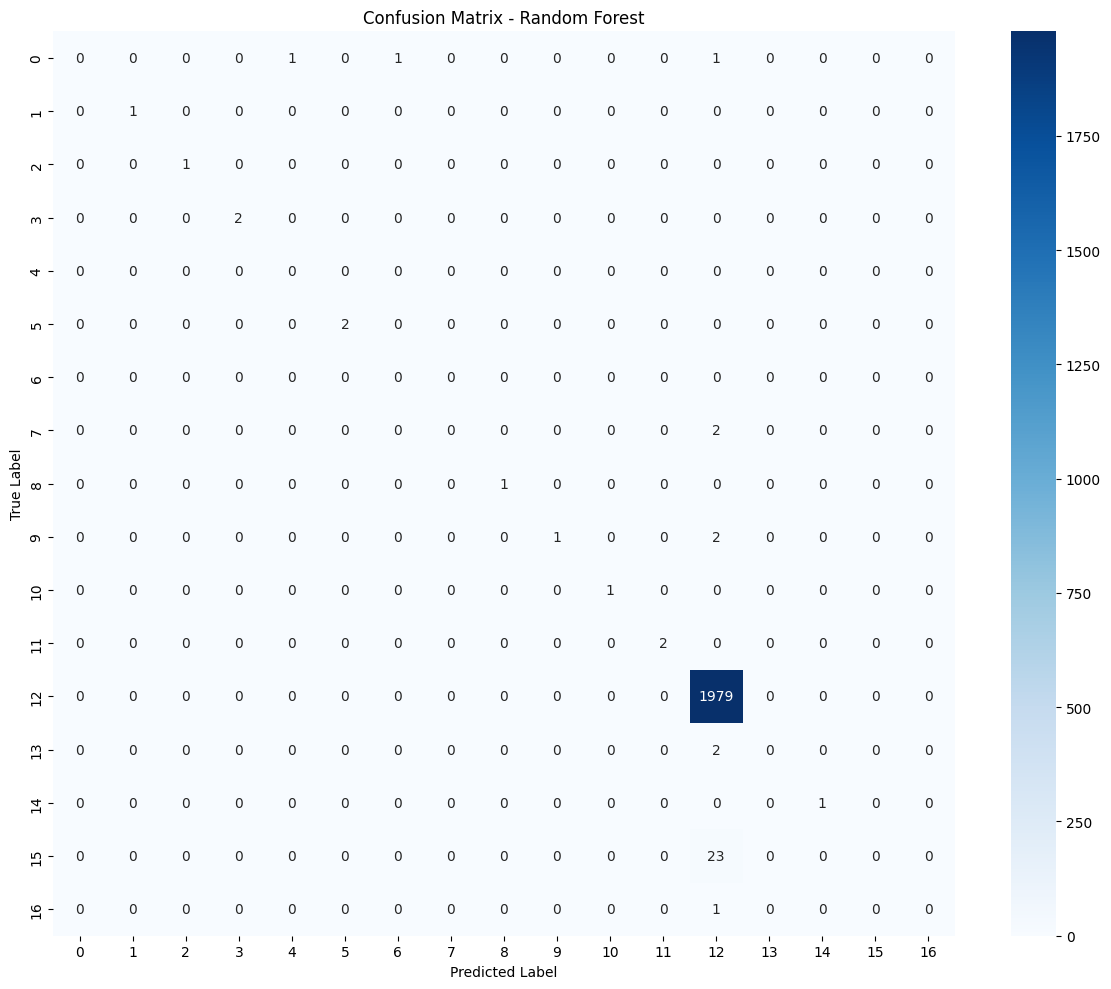

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive c

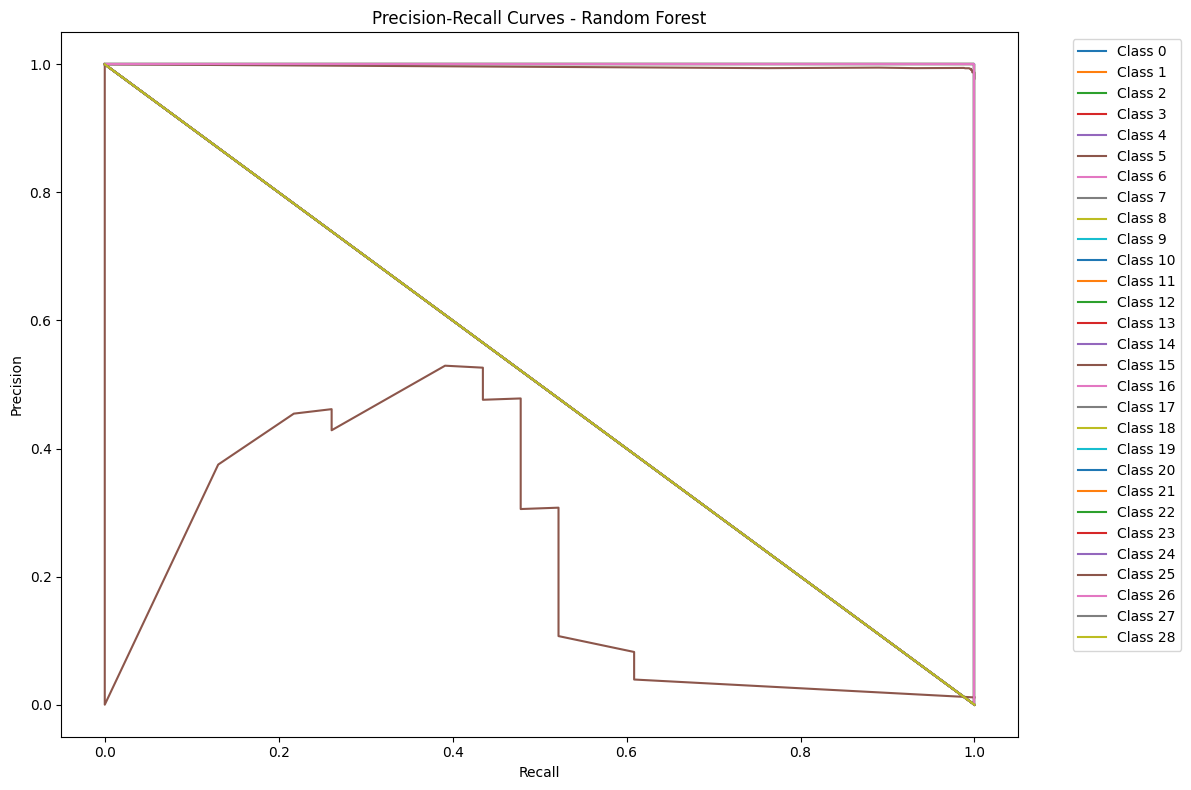


Detailed Analysis for Random Forest:

Class -1:
Total instances: 3
Correctly detected: 0
Missed: 3
False positives: 0
Recall: 0.00%
Precision: 0.00%

Class 1:
Total instances: 1
Correctly detected: 1
Missed: 0
False positives: 0
Recall: 100.00%
Precision: 100.00%

Class 2:
Total instances: 1
Correctly detected: 1
Missed: 0
False positives: 0
Recall: 100.00%
Precision: 100.00%

Class 3:
Total instances: 2
Correctly detected: 2
Missed: 0
False positives: 0
Recall: 100.00%
Precision: 100.00%

Class 7:
Total instances: 2
Correctly detected: 2
Missed: 0
False positives: 0
Recall: 100.00%
Precision: 100.00%

Class 9:
Total instances: 2
Correctly detected: 0
Missed: 2
False positives: 0
Recall: 0.00%
Precision: 0.00%

Class 10:
Total instances: 1
Correctly detected: 1
Missed: 0
False positives: 0
Recall: 100.00%
Precision: 100.00%

Class 11:
Total instances: 3
Correctly detected: 1
Missed: 2
False positives: 0
Recall: 33.33%
Precision: 100.00%

Class 13:
Total instances: 1
Correctly detected

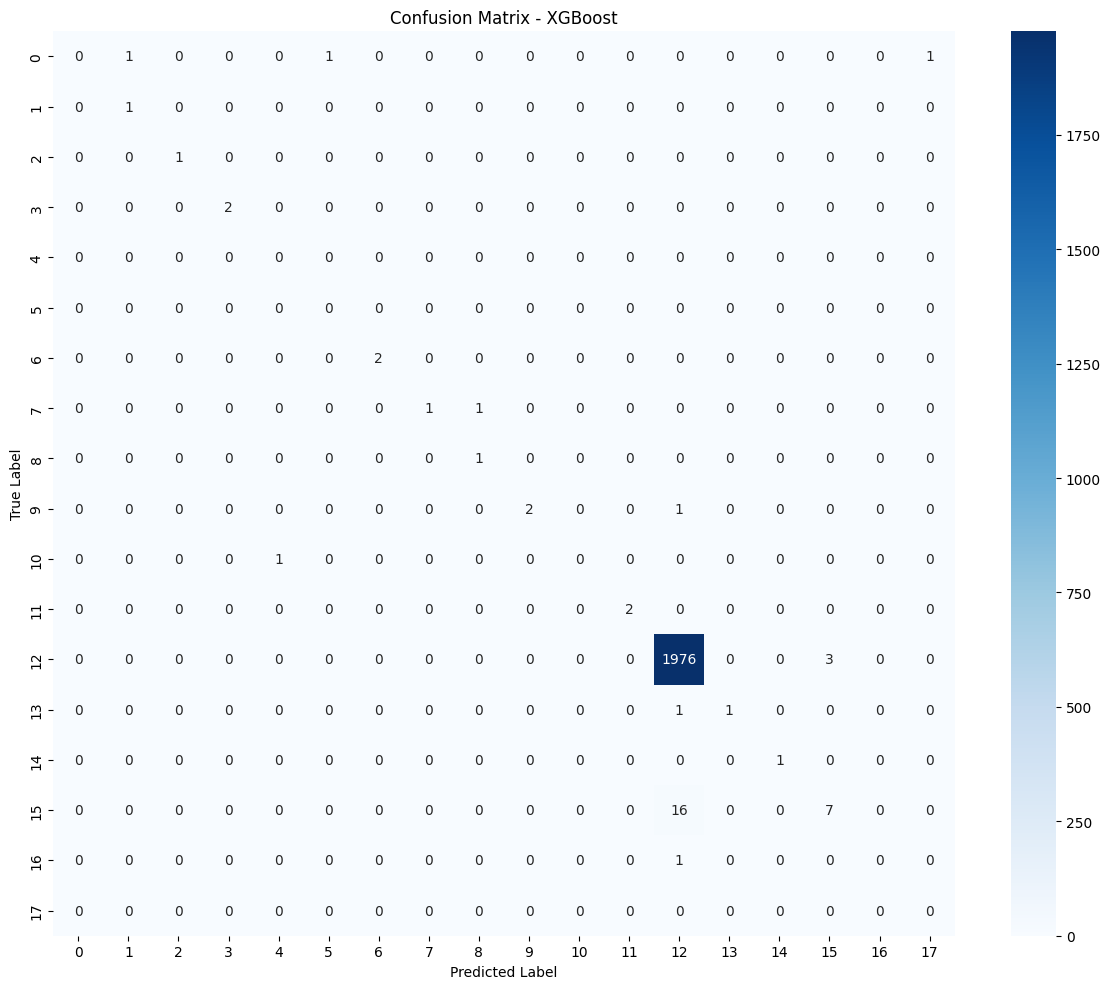

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive c

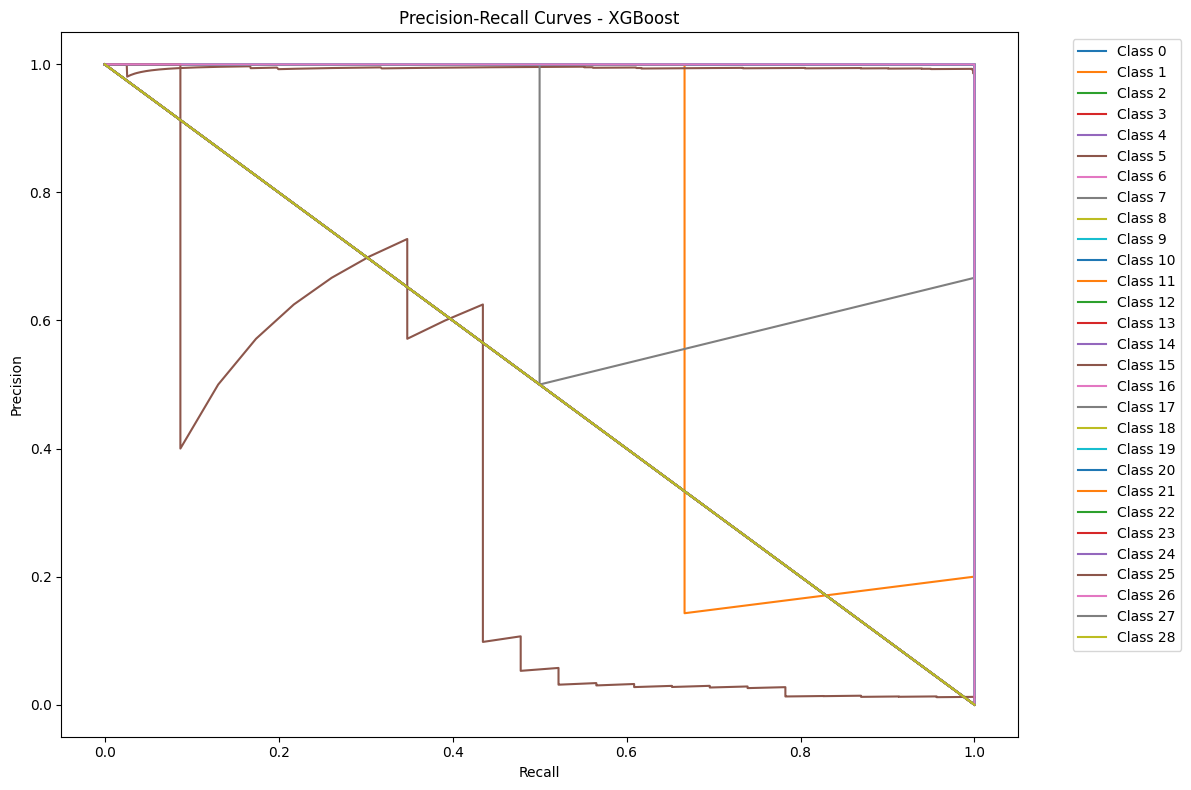


Detailed Analysis for XGBoost:

Class -1:
Total instances: 3
Correctly detected: 0
Missed: 3
False positives: 0
Recall: 0.00%
Precision: 0.00%

Class 1:
Total instances: 1
Correctly detected: 1
Missed: 0
False positives: 1
Recall: 100.00%
Precision: 50.00%

Class 2:
Total instances: 1
Correctly detected: 1
Missed: 0
False positives: 0
Recall: 100.00%
Precision: 100.00%

Class 3:
Total instances: 2
Correctly detected: 2
Missed: 0
False positives: 0
Recall: 100.00%
Precision: 100.00%

Class 7:
Total instances: 2
Correctly detected: 2
Missed: 0
False positives: 0
Recall: 100.00%
Precision: 100.00%

Class 9:
Total instances: 2
Correctly detected: 1
Missed: 1
False positives: 0
Recall: 50.00%
Precision: 100.00%

Class 10:
Total instances: 1
Correctly detected: 1
Missed: 0
False positives: 1
Recall: 100.00%
Precision: 50.00%

Class 11:
Total instances: 3
Correctly detected: 2
Missed: 1
False positives: 0
Recall: 66.67%
Precision: 100.00%

Class 13:
Total instances: 1
Correctly detected: 0
M

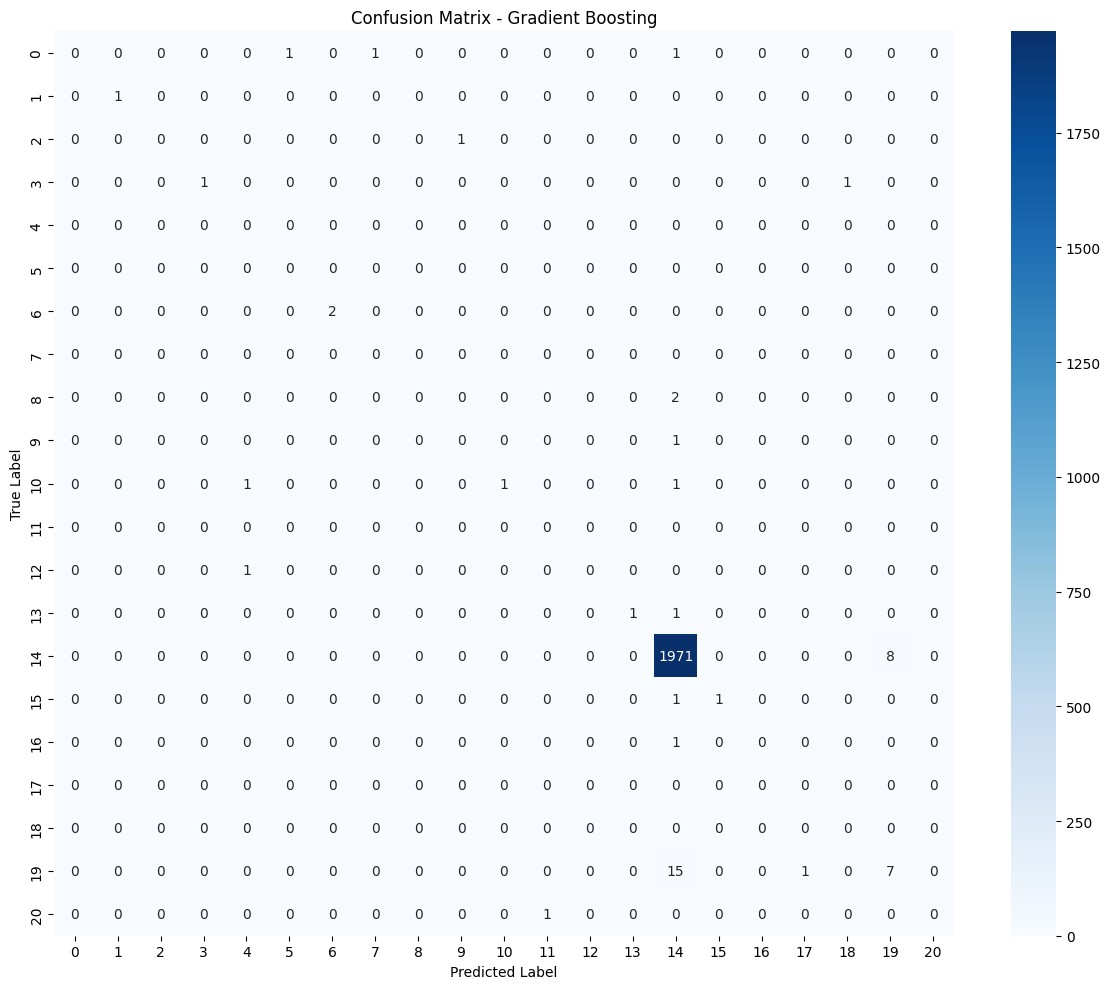

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive c

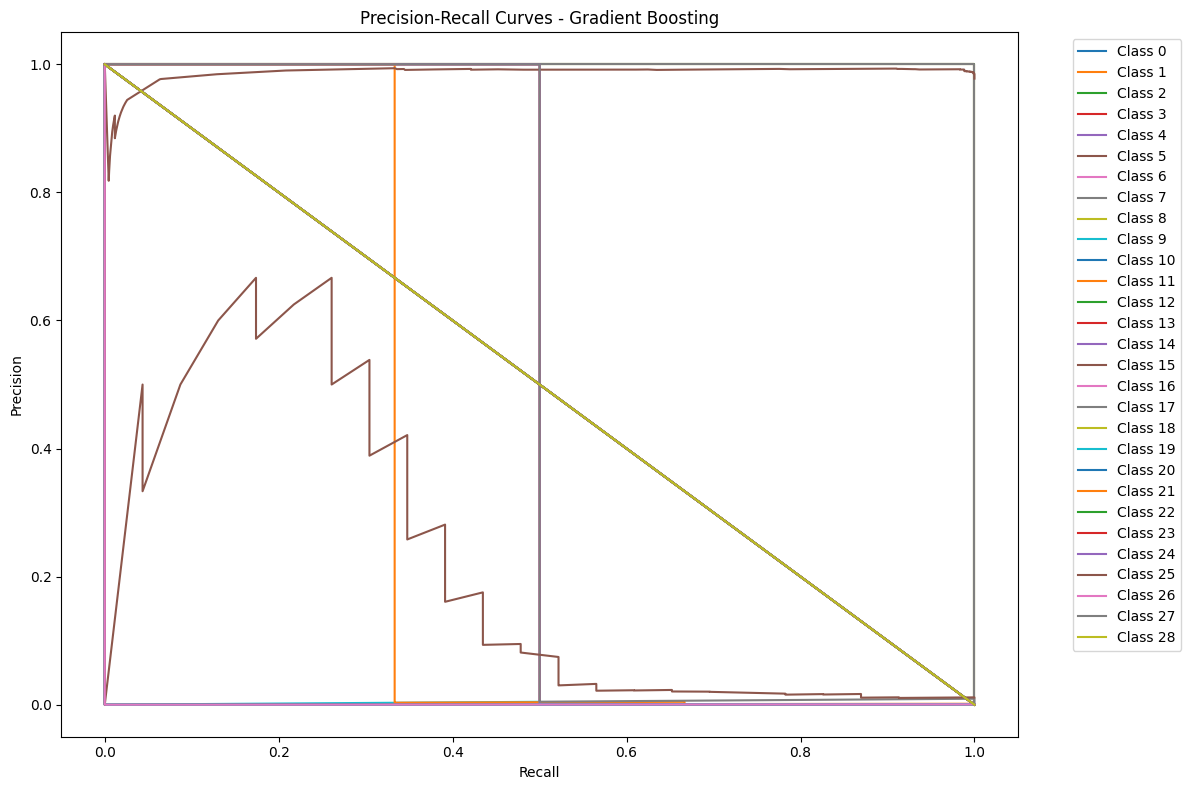


Detailed Analysis for Gradient Boosting:

Class -1:
Total instances: 3
Correctly detected: 0
Missed: 3
False positives: 0
Recall: 0.00%
Precision: 0.00%

Class 1:
Total instances: 1
Correctly detected: 1
Missed: 0
False positives: 0
Recall: 100.00%
Precision: 100.00%

Class 2:
Total instances: 1
Correctly detected: 0
Missed: 1
False positives: 0
Recall: 0.00%
Precision: 0.00%

Class 3:
Total instances: 2
Correctly detected: 1
Missed: 1
False positives: 0
Recall: 50.00%
Precision: 100.00%

Class 7:
Total instances: 2
Correctly detected: 2
Missed: 0
False positives: 0
Recall: 100.00%
Precision: 100.00%

Class 9:
Total instances: 2
Correctly detected: 0
Missed: 2
False positives: 0
Recall: 0.00%
Precision: 0.00%

Class 10:
Total instances: 1
Correctly detected: 0
Missed: 1
False positives: 1
Recall: 0.00%
Precision: 0.00%

Class 11:
Total instances: 3
Correctly detected: 1
Missed: 2
False positives: 0
Recall: 33.33%
Precision: 100.00%

Class 13:
Total instances: 1
Correctly detected: 0
M

In [ ]:
import numpy as np
import pandas as pd
from scipy import sparse
import pickle
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import (classification_report, confusion_matrix,
                           precision_recall_curve, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

class AMLModel:
    def __init__(self):
        self.rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced')
        self.xgb_model = None
        self.gbm_model = GradientBoostingClassifier(n_estimators=100)
        with open('aml_data/label_encoders.pkl', 'rb') as f:
            enc = pickle.load(f)
            self.label_encoders = enc['feature_encoders']
            self.target_encoder = enc['target_encoder']

    def initialize_models(self, unique_classes):
        """Initialize models with the correct number of classes"""
        self.unique_classes = np.array(sorted(unique_classes))
        self.xgb_model = xgb.XGBClassifier(
            objective='multi:softmax',
            eval_metric='mlogloss',
            num_class=len(self.unique_classes),
            use_label_encoder=False
        )

    def train(self, X_train, y_train):
        print("\nTraining models...")
        print("Class distribution in training data:")
        print(pd.Series(y_train).value_counts())
        self.rf_model.fit(X_train, y_train)
        self.xgb_model.fit(X_train, y_train)
        self.gbm_model.fit(X_train, y_train)

    def overall_suspicious_stats(self, y_true, y_pred):
        # Suspicious classes: all except 17
        suspicious_mask = y_true != 17
        total_suspicious = np.sum(suspicious_mask)
        correctly_detected = np.sum((y_true != 17) & (y_pred == y_true))
        detection_rate = correctly_detected / total_suspicious if total_suspicious > 0 else 0

        print("\nOverall Suspicious Transaction Detection:")
        print(f"Total suspicious transactions: {total_suspicious}")
        print(f"Correctly detected: {correctly_detected}")
        print(f"Overall detection rate: {detection_rate:.2%}")

    def plot_confusion_matrix(self, y_true, y_pred, model_name):
        """Plot confusion matrix"""
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - {model_name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()

    def plot_precision_recall_curve(self, y_true, y_pred_proba, model_name):
        """Plot precision-recall curve for each class"""
        plt.figure(figsize=(12, 8))
        for i in range(y_pred_proba.shape[1]):
            precision, recall, _ = precision_recall_curve(
                (y_true == i).astype(int),
                y_pred_proba[:, i]
            )
            plt.plot(recall, precision, label=f'Class {i}')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curves - {model_name}')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    def analyze_suspicious_transactions(self, y_true, y_pred, model_name):
        """Detailed analysis of suspicious transaction detection"""
        print(f"\nDetailed Analysis for {model_name}:")

        for class_idx in np.unique(y_true):
            if class_idx != 17:  # Skip the normal class
                true_pos = np.sum((y_true == class_idx) & (y_pred == class_idx))
                false_neg = np.sum((y_true == class_idx) & (y_pred != class_idx))
                false_pos = np.sum((y_true != class_idx) & (y_pred == class_idx))
                total = np.sum(y_true == class_idx)

                if total > 0:
                    recall = true_pos / total
                    precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0

                    print(f"\nClass {class_idx}:")
                    print(f"Total instances: {total}")
                    print(f"Correctly detected: {true_pos}")
                    print(f"Missed: {false_neg}")
                    print(f"False positives: {false_pos}")
                    print(f"Recall: {recall:.2%}")
                    print(f"Precision: {precision:.2%}")

    def evaluate(self, X_test, y_test):
        """Evaluate all models"""
        models = {
            'Random Forest': self.rf_model,
            'XGBoost': self.xgb_model,
            'Gradient Boosting': self.gbm_model
        }

        for name, model in models.items():
            print(f"\n{name} Results:")
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)

            # Print classification report
            print("\nClassification Report:")
            print(classification_report(y_test, y_pred, zero_division=0))

            # Plot confusion matrix
            self.plot_confusion_matrix(y_test, y_pred, name)

            # Plot precision-recall curves
            self.plot_precision_recall_curve(y_test, y_pred_proba, name)

            # Analyze suspicious transactions
            self.analyze_suspicious_transactions(y_test, y_pred, name)

            # Add overall suspicious stats
            self.overall_suspicious_stats(y_test, y_pred)

    def save_models(self):
        """Save trained models"""
        with open('aml_data/trained_models.pkl', 'wb') as f:
            pickle.dump({
                'rf': self.rf_model,
                'xgb': self.xgb_model,
                'gbm': self.gbm_model
            }, f)
        print("\nModels saved successfully")

# Load and prepare data
print("Loading data...")
X_train = sparse.load_npz('aml_data/X_train.npz')
y_train = np.load('aml_data/y_train.npy')
X_test = sparse.load_npz('aml_data/X_test.npz')
y_test = np.load('aml_data/y_test.npy')

# Convert sparse matrices to dense
X_train = X_train.toarray()
X_test = X_test.toarray()

# Get number of unique classes
n_classes = len(np.unique(np.concatenate([y_train, y_test])))
print(f"Total number of unique classes: {n_classes}")
print("All classes:", np.unique(np.concatenate([y_train, y_test])))

# Get unique classes from training data only
unique_train_classes = np.unique(y_train)
# Create a mapping from original class to new contiguous class
class_mapping = {orig: new for new, orig in enumerate(unique_train_classes)}

# Remap y_train and y_test
y_train_remap = np.array([class_mapping[y] for y in y_train])
# For y_test, map only those classes present in training (others will be ignored in evaluation)
y_test_remap = np.array([class_mapping[y] if y in class_mapping else -1 for y in y_test])

# Now, initialize XGBoost with num_class = len(unique_train_classes)
model = AMLModel()
model.initialize_models(np.arange(len(unique_train_classes)))
model.train(X_train, y_train_remap)
model.evaluate(X_test, y_test_remap)
model.save_models()